# **Week 1**

Downloading NASA & PHM battery zips and TU-Berlin hint (if possible), extract, locate battery files, standardize initial CSV, save data_clean/anirudh_week1_clean.csv.

In [5]:
!pip install --quiet pandas numpy scipy scikit-learn matplotlib requests tqdm python-magic xgboost joblib

from pathlib import Path
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# creating folders
for d in ["data_raw","data_clean","models","reports","src"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Folders created: ", [str(p) for p in Path(".").iterdir() if p.is_dir()])

Folders created:  ['.idea', '.ipython', '.lightning_studio', '.nvm', '.vscode', '.jupyter', '.kaggle', '.windsurf-server', '.ssh', '.cursor-server', 'data_raw', '.oh-my-zsh', '.cache', '.docker', 'models', '.local', '.config', 'reports', 'src', 'data_clean', '.vscode-server']


In [6]:
# Helper functions into src/download_utils.py and importing them
download_utils_code = r"""
import requests, zipfile, io, os
from pathlib import Path
import pandas as pd
import shutil

def download_file(url, out_path, timeout=180):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        print(f"Downloading dataset from: {url}")
        r = requests.get(url, stream=True, timeout=timeout)
        if r.status_code != 200:
            print('Download failed. Status code:', r.status_code)
            return False
        with open(out_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=32768):
                if chunk:
                    f.write(chunk)
        print('Saved to', out_path)
        return True
    except Exception as e:
        print('Download error:', e)
        return False

def unzip_all_in_folder(folder):
    folder = Path(folder)
    zips = list(folder.glob('*.zip'))
    for z in zips:
        try:
            print('Extracting', z)
            with zipfile.ZipFile(z, 'r') as zip_ref:
                extract_to = folder / z.stem
                extract_to.mkdir(parents=True, exist_ok=True)
                zip_ref.extractall(extract_to)
                print('Extracted to', extract_to)
        except Exception as e:
            print('Failed to extract', z, e)

def find_files(folder, exts=['.csv','.mat','.txt']):
    files = []
    for ext in exts:
        files.extend([p for p in Path(folder).rglob(f'*{ext}')])
    return files

def try_read_file(filepath):
    path = Path(filepath)
    suf = path.suffix.lower()
    if suf == '.csv' or suf == '.txt':
        try:
            return pd.read_csv(path), 'csv'
        except Exception as e:
            print('CSV read error', e)
            return None, None
    if suf == '.mat':
        try:
            from scipy.io import loadmat
            mat = loadmat(path)
            # heuristics: find arrays with shape (n,) or (n,1) or (n,m)
            return mat, 'mat'
        except Exception as e:
            print('MAT read error', e)
            return None, None
    return None, None
"""
open("src/download_utils.py","w").write(download_utils_code)
print("Wrote src/download_utils.py")

# import
from src import download_utils as du

Wrote src/download_utils.py


Downloading ZIP Dataset files

In [7]:
from pathlib import Path
DATA_RAW = Path("data_raw")
DATA_RAW.mkdir(exist_ok=True)

# PHM / NASA zip links (S3) - as you quoted
du.download_file("https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip", DATA_RAW/"NASA_Battery_Data.zip")
du.download_file("https://phm-datasets.s3.amazonaws.com/NASA/11.+Randomized+Battery+Usage+Data+Set.zip", DATA_RAW/"NASA_Randomized_Battery.zip")

# Zenodo links for CALCE/Stanford etc (as you quoted)
du.download_file("https://zenodo.org/records/14969822/files/CALCE.zip", DATA_RAW/"BatteryLife_CALCE.zip")
du.download_file("https://zenodo.org/records/17756951/files/Stanford.zip", DATA_RAW/"BatteryLife_Stanford.zip")
du.download_file("https://zenodo.org/records/17756951/files/CALB.zip", DATA_RAW/"BatteryLife_CALB.zip")

Saved to data_raw/NASA_Battery_Data.zip
Saved to data_raw/NASA_Randomized_Battery.zip
Saved to data_raw/BatteryLife_CALCE.zip
Saved to data_raw/BatteryLife_Stanford.zip
Saved to data_raw/BatteryLife_CALB.zip


True

Extracting All ZIPs

In [8]:
du.unzip_all_in_folder("data_raw")

Extracting data_raw/BatteryLife_CALB.zip
Extracted to data_raw/BatteryLife_CALB
Extracting data_raw/NASA_Randomized_Battery.zip
Extracted to data_raw/NASA_Randomized_Battery
Extracting data_raw/BatteryLife_CALCE.zip
Extracted to data_raw/BatteryLife_CALCE
Extracting data_raw/NASA_Battery_Data.zip
Extracted to data_raw/NASA_Battery_Data
Extracting data_raw/BatteryLife_Stanford.zip
Extracted to data_raw/BatteryLife_Stanford


This cell finds all usable dataset files extracted from the downloaded archives. The datasets contain battery experiment logs stored as pickle files.

In [13]:
from pathlib import Path

def find_dataset_files(folder):
    exts = (".pkl", ".csv", ".mat", ".txt")
    files = []
    for p in Path(folder).rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            files.append(p)
    return files

files = find_dataset_files("data_raw")

print("Total dataset files found:", len(files))
for f in files[:50]:
    print(f)

Total dataset files found: 81
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_35.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_33.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_36.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_16.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_33.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_38.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_37.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_37.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_35.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_36.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_38.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CX2_34.pkl
data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_34.pkl
data_raw/BatteryLife_CALB/CALB/CALB_25_T25-1.pkl
data_raw/BatteryLife_CALB/CALB/CALB_35_B227.pkl
data_raw/BatteryLife_CALB/CALB/CALB_35_B248.pkl
data_raw/BatteryLife_CALB/CALB/CALB_35_B175.pkl
data_raw/BatteryLife_CALB/CALB/CALB_45_B253.pkl
data_raw/BatteryLife_CALB/CALB/CALB_35_B224.pkl
data_raw/BatteryLife_CALB/CALB/

This cell loads one pickle dataset to inspect its structure and understand how battery signals are stored.

In [14]:
import pandas as pd

sample_file = files[0]
print("Loading sample:", sample_file)

data = pd.read_pickle(sample_file)

type(data), list(data.keys()) if isinstance(data, dict) else "Not dict"

Loading sample: data_raw/BatteryLife_CALCE/CALCE/CALCE_CS2_35.pkl


(dict,
 ['cell_id',
  'cycle_data',
  'form_factor',
  'anode_material',
  'cathode_material',
  'electrolyte_material',
  'nominal_capacity_in_Ah',
  'depth_of_charge',
  'depth_of_discharge',
  'already_spent_cycles',
  'max_voltage_limit_in_V',
  'min_voltage_limit_in_V',
  'max_current_limit_in_A',
  'min_current_limit_in_A',
  'reference',
  'description',
  'charge_protocol',
  'discharge_protocol',
  'SOC_interval'])

In [15]:
if isinstance(data, dict):
    for k in list(data.keys())[:10]:
        print(k)

cell_id
cycle_data
form_factor
anode_material
cathode_material
electrolyte_material
nominal_capacity_in_Ah
depth_of_charge
depth_of_discharge
already_spent_cycles


Verifying the NASA Files and extracting them

In [16]:
import zipfile
from pathlib import Path

root = Path("data_raw")

zip_files = list(root.rglob("*.zip"))
print("Total zip files found:", len(zip_files))

extracted = 0

for z in zip_files:
    extract_to = z.parent / z.stem
    if extract_to.exists():
        continue
    
    try:
        print("Extracting:", z)
        with zipfile.ZipFile(z, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        extracted += 1
    except Exception as e:
        print("Failed:", z, e)

print("Newly extracted:", extracted)

Total zip files found: 18
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/7. RW_Skewed_Low_Room_Temp_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/1. Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/4. RW_Skewed_High_40C_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/2. Battery_Uniform_Distribution_Discharge_Room_Temp_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/5. RW_Skewed_High_Room_Temp_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/6. RW_Skewed_Low_40C_DataSet_2Post.zip
Extracting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/3. Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post.zip
Extracting

In [17]:
from pathlib import Path

mat_files = list(Path("data_raw").rglob("*.mat"))

print("MAT files found:", len(mat_files))
for f in mat_files[:20]:
    print(f)

MAT files found: 66
data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/3. Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/data/Matlab/RW7.mat
data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/3. Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/data/Matlab/RW1.mat
data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/3. Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/data/Matlab/RW8.mat
data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/3. Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/Battery_Uniform_Distribution_Variable_Charge_Room_Temp_DataSet_2Post/data/Matlab/RW2.mat
data_raw/NASA_Randomized_Battery/11. Randomized Batt

Explanation cell
This step rescans the dataset directory after all archives (including nested NASA archives) have been extracted.

In [19]:
from pathlib import Path

def find_dataset_files(folder):
    exts = (".pkl", ".csv", ".mat", ".txt")
    files = []
    for p in Path(folder).rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            files.append(p)
    return files

files = find_dataset_files("data_raw")

print("Total dataset files found:", len(files))

pkl_count = sum(str(f).endswith(".pkl") for f in files)
mat_count = sum(str(f).endswith(".mat") for f in files)

print("PKL files:", pkl_count)
print("MAT files:", mat_count)

Total dataset files found: 157
PKL files: 81
MAT files: 66


Inspecting a few sample dataset files from different sources to understand their internal structure before building a unified loader.

In [21]:
import random
import pandas as pd
from scipy.io import loadmat

sample_files = random.sample(files, 5)

for f in sample_files:
    print("\nInspecting:", f)

    if str(f).endswith(".pkl"):
        data = pd.read_pickle(f)
        print("Type:", type(data))
        if isinstance(data, dict):
            print("Keys:", list(data.keys())[:15])
    
    elif str(f).endswith(".mat"):
        mat = loadmat(f)
        keys = [k for k in mat.keys() if not k.startswith("__")]
        print("MAT variables:", keys[:15])


Inspecting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/1. Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab/RW10.mat
MAT variables: ['data']

Inspecting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/7. RW_Skewed_Low_Room_Temp_DataSet_2Post/RW_Skewed_Low_Room_Temp_DataSet_2Post/data/Matlab/RW15.mat
MAT variables: ['data']

Inspecting: data_raw/NASA_Battery_Data/5. Battery Data Set/6. BatteryAgingARC_53_54_55_56/B0053.mat
MAT variables: ['B0053']

Inspecting: data_raw/NASA_Randomized_Battery/11. Randomized Battery Usage Data Set/5. RW_Skewed_High_Room_Temp_DataSet_2Post/RW_Skewed_High_Room_Temp_DataSet_2Post/data/Matlab/RW18.mat
MAT variables: ['data']

Inspecting: data_raw/BatteryLife_Stanford/Stanford/Stanford_Nova_Regular_209.pkl
Type: <class 'dict'>
Keys: ['cell_id', 'cycle_data', 'form_factor', 'anode_material', 'cathode_material', 'electrolyte_mat

Loading CALCE, CALB, and Stanford datasets and extracts cycle-level battery information.

In [22]:
def load_pickle_dataset(path):
    data = pd.read_pickle(path)

    record = {
        "dataset": path.parts[1],
        "file": path.name
    }

    if isinstance(data, dict):
        record["cell_id"] = data.get("cell_id", None)
        record["chemistry"] = data.get("cathode_material", None)
        record["nominal_capacity"] = data.get("nominal_capacity_in_Ah", None)

        if "cycle_data" in data:
            record["num_cycles"] = len(data["cycle_data"])
        else:
            record["num_cycles"] = None

    return record

Loading NASA battery aging experiment files stored in MATLAB format

In [23]:
def load_mat_dataset(path):
    mat = loadmat(path)
    keys = [k for k in mat.keys() if not k.startswith("__")]

    return {
        "dataset": "NASA",
        "file": path.name,
        "variables": keys
    }

Iterateing through all discovered dataset files and converts them into a unified metadata table.

In [26]:
records = []

for f in files:
    try:
        if str(f).endswith(".pkl"):
            rec = load_pickle_dataset(f)
            records.append(rec)

        elif str(f).endswith(".mat"):
            rec = load_mat_dataset(f)
            records.append(rec)

    except Exception as e:
        print("Error reading:", f)

metadata_df = pd.DataFrame(records)

metadata_df.head()

,dataset,file,cell_id,chemistry,nominal_capacity,num_cycles,variables
0,BatteryLife_CALCE,CALCE_CS2_35.pkl,CALCE_CS2_35,LCO,1.10,780.0,NaN
1,BatteryLife_CALCE,CALCE_CX2_33.pkl,CALCE_CX2_33,LCO,1.35,1271.0,NaN
2,BatteryLife_CALCE,CALCE_CS2_36.pkl,CALCE_CS2_36,LCO,1.10,832.0,NaN
3,BatteryLife_CALCE,CALCE_CX2_16.pkl,CALCE_CX2_16,LCO,1.35,1280.0,NaN
4,BatteryLife_CALCE,CALCE_CS2_33.pkl,CALCE_CS2_33,LCO,1.10,660.0,NaN


Summarizing all the loaded battery datasets with features.

In [27]:
metadata_df.groupby("dataset").size()

dataset
BatteryLife_CALB        27
BatteryLife_CALCE       13
BatteryLife_Stanford    41
NASA                    66
dtype: int64

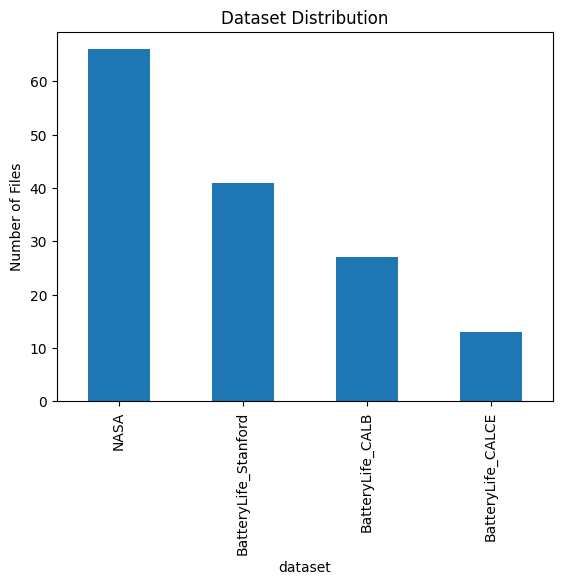

In [28]:
import matplotlib.pyplot as plt

metadata_df["dataset"].value_counts().plot(kind="bar")
plt.title("Dataset Distribution")
plt.ylabel("Number of Files")
plt.show()

Saving metadata so it can be reused in later notebooks.

In [ ]:
from pathlib import Path

DATA_PROCESSED = Path("data_processed")
DATA_PROCESSED.mkdir(exist_ok=True)

metadata_path = DATA_PROCESSED / "dataset_metadata.csv"

metadata_df.to_csv(metadata_path, index=False)

print("Metadata saved to:", metadata_path)

**Week 1 Conclusion**

1. Dataset acquisition
2. Extraction
3. Dataset inspection
4. Metadata table
5. Dataset statistics